In [ ]:
# Анализ распределения классов в сгенерированных синтетических данных
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict, Counter
import seaborn as sns

# Настройки визуализации
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 12

# Пути к данным
LABELS_PATH = Path("data/synthetic_adaptive_final/labels")
IMAGES_PATH = Path("data/synthetic_adaptive_final/images")

# Имена классов (из вашей конфигурации)
CLASS_NAMES = {
    0: 'defect_type_1',
    1: 'defect_type_2', 
    2: 'defect_type_3',
    3: 'defect_type_4'
}
NUM_CLASSES = 4

In [5]:
# Функция для парсинга YOLO разметки
def parse_yolo_label(label_path):
    """Парсит YOLO файл и возвращает список классов и их количество"""
    if not label_path.exists():
        return [], 0
    
    classes = []
    num_bboxes = 0
    
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                class_id = int(parts[0])
                classes.append(class_id)
                num_bboxes += 1
    
    return classes, num_bboxes

In [6]:
# Анализ всех label файлов
print("="*80)
print("📊 АНАЛИЗ РАСПРЕДЕЛЕНИЯ КЛАССОВ В СИНТЕТИЧЕСКИХ ДАННЫХ")
print("="*80)

# Сбор статистики
all_label_files = list(LABELS_PATH.glob("*.txt"))
print(f"\n📁 Найдено label файлов: {len(all_label_files)}")

# Счетчики
class_counter = Counter()  # Общее количество bbox по классам
images_per_class = defaultdict(set)  # Изображения, содержащие каждый класс
images_with_multiple_classes = set()  # Изображения с несколькими классами
bboxes_per_image = []  # Количество bbox на изображение
classes_per_image = []  # Количество классов на изображение
empty_images = []  # Изображения без дефектов

# Детальная статистика
for label_file in all_label_files:
    classes, num_bboxes = parse_yolo_label(label_file)
    
    image_name = label_file.stem
    
    if num_bboxes == 0:
        empty_images.append(image_name)
    else:
        bboxes_per_image.append(num_bboxes)
        classes_per_image.append(len(set(classes)))
        
        if len(set(classes)) > 1:
            images_with_multiple_classes.add(image_name)
        
        for cls in classes:
            class_counter[cls] += 1
            images_per_class[cls].add(image_name)

# Проверка наличия соответствующих изображений
image_files = set(f.stem for f in IMAGES_PATH.glob("*.png"))
image_files.update(f.stem for f in IMAGES_PATH.glob("*.jpg"))

labels_without_images = []
for label_file in all_label_files:
    if label_file.stem not in image_files:
        labels_without_images.append(label_file.stem)

print(f"📁 Найдено изображений: {len(image_files)}")
print(f"⚠️ Label файлов без изображений: {len(labels_without_images)}")

📊 АНАЛИЗ РАСПРЕДЕЛЕНИЯ КЛАССОВ В СИНТЕТИЧЕСКИХ ДАННЫХ

📁 Найдено label файлов: 7336
📁 Найдено изображений: 7336
⚠️ Label файлов без изображений: 0


In [7]:
# Сводная таблица по классам
print("\n" + "="*80)
print("📈 СТАТИСТИКА ПО КЛАССАМ")
print("="*80)

total_bboxes = sum(class_counter.values())
total_images_with_defects = len(all_label_files) - len(empty_images)

data = []
for class_id in range(NUM_CLASSES):
    count = class_counter[class_id]
    pct = (count / total_bboxes * 100) if total_bboxes > 0 else 0
    images = len(images_per_class[class_id])
    avg_per_image = count / images if images > 0 else 0
    
    data.append({
        'Класс': f"{class_id} - {CLASS_NAMES[class_id]}",
        'BBoxes': count,
        '%': f"{pct:.1f}%",
        'Изображений': images,
        'BBox/Изобр': f"{avg_per_image:.2f}"
    })

df_stats = pd.DataFrame(data)
print(df_stats.to_string(index=False))

print(f"\n📊 ВСЕГО:")
print(f"   BBoxes: {total_bboxes}")
print(f"   Изображений с дефектами: {total_images_with_defects}")
print(f"   Пустых изображений: {len(empty_images)}")
print(f"   Среднее bbox на изображение: {total_bboxes/total_images_with_defects:.2f}" if total_images_with_defects > 0 else "   Нет дефектов")


📈 СТАТИСТИКА ПО КЛАССАМ
            Класс  BBoxes     %  Изображений BBox/Изобр
0 - defect_type_1    4932 39.6%         3717       1.33
1 - defect_type_2     434  3.5%          425       1.02
2 - defect_type_3    3711 29.8%         3201       1.16
3 - defect_type_4    3390 27.2%         3051       1.11

📊 ВСЕГО:
   BBoxes: 12467
   Изображений с дефектами: 7336
   Пустых изображений: 0
   Среднее bbox на изображение: 1.70


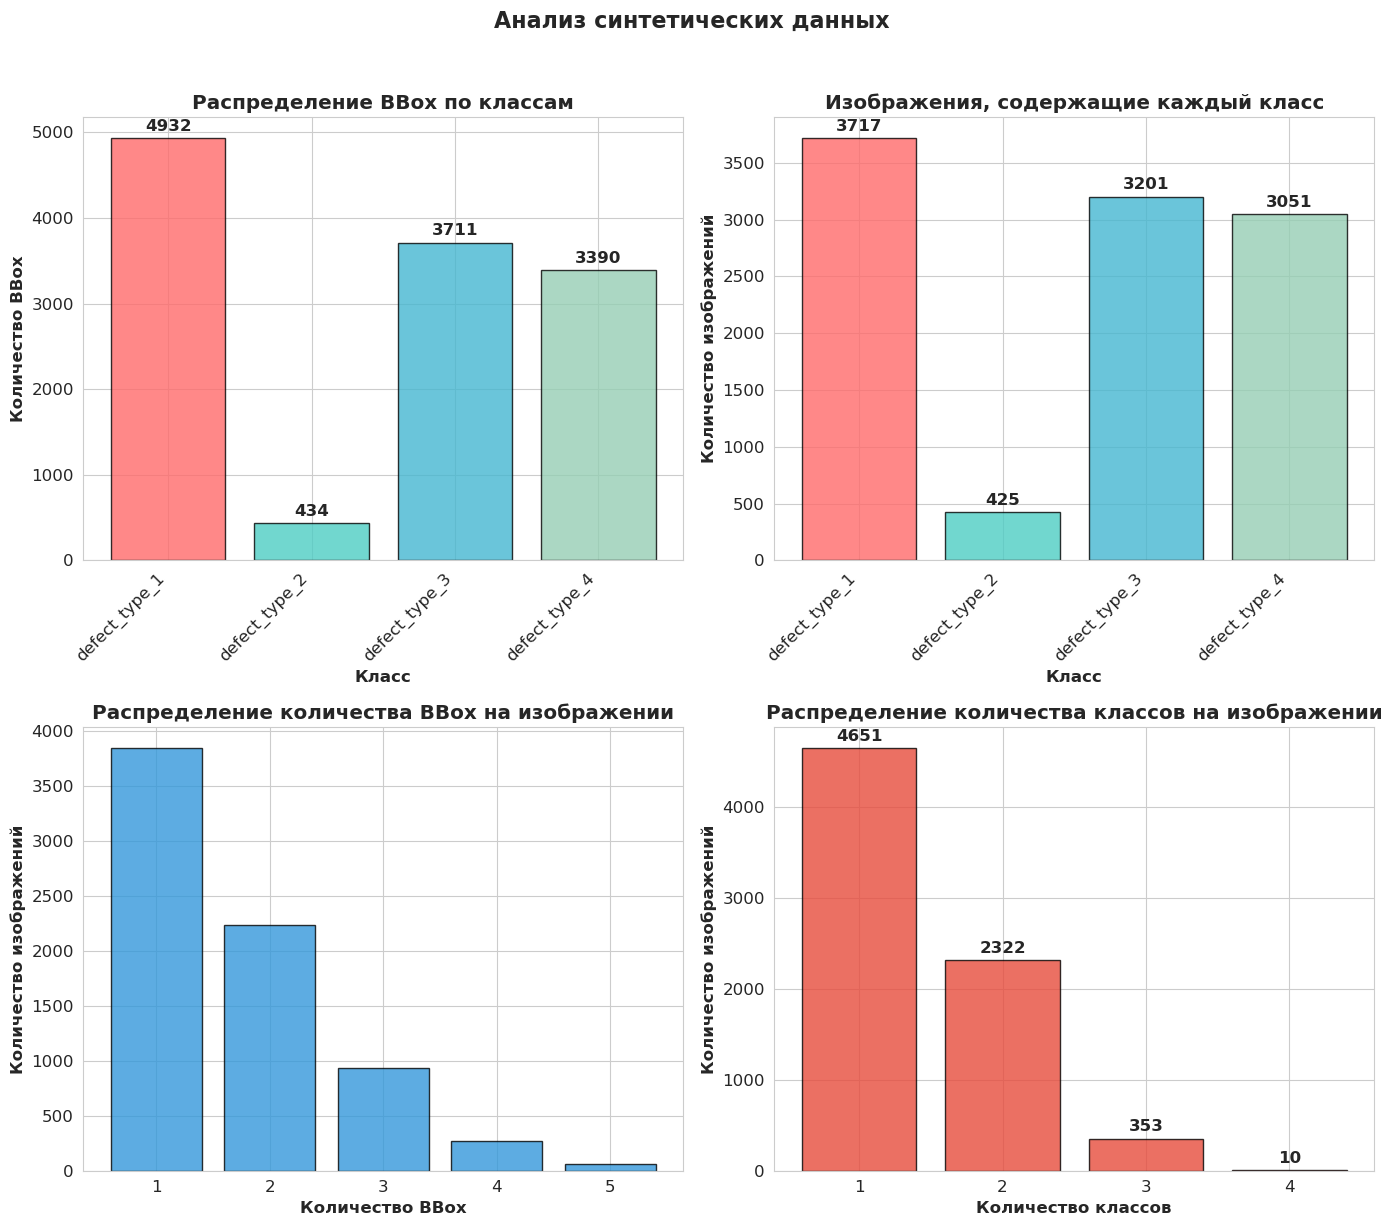

In [8]:
# Визуализация 1: Распределение классов
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Общее количество bbox по классам
ax1 = axes[0, 0]
classes = list(range(NUM_CLASSES))
counts = [class_counter[i] for i in classes]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
bars = ax1.bar(classes, counts, color=colors, alpha=0.8, edgecolor='black')
ax1.set_xlabel('Класс', fontweight='bold')
ax1.set_ylabel('Количество BBox', fontweight='bold')
ax1.set_title('Распределение BBox по классам', fontweight='bold')
ax1.set_xticks(classes)
ax1.set_xticklabels([CLASS_NAMES[i] for i in classes], rotation=45, ha='right')

# Добавляем значения над столбцами
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
             f'{count}', ha='center', va='bottom', fontweight='bold')

# 2. Количество изображений с каждым классом
ax2 = axes[0, 1]
img_counts = [len(images_per_class[i]) for i in classes]
bars2 = ax2.bar(classes, img_counts, color=colors, alpha=0.8, edgecolor='black')
ax2.set_xlabel('Класс', fontweight='bold')
ax2.set_ylabel('Количество изображений', fontweight='bold')
ax2.set_title('Изображения, содержащие каждый класс', fontweight='bold')
ax2.set_xticks(classes)
ax2.set_xticklabels([CLASS_NAMES[i] for i in classes], rotation=45, ha='right')

for bar, count in zip(bars2, img_counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(img_counts)*0.01,
             f'{count}', ha='center', va='bottom', fontweight='bold')

# 3. Распределение количества bbox на изображение
ax3 = axes[1, 0]
if bboxes_per_image:
    max_bboxes = max(bboxes_per_image)
    bbox_hist, bins = np.histogram(bboxes_per_image, bins=range(1, max_bboxes+2))
    ax3.bar(range(1, max_bboxes+1), bbox_hist, color='#3498db', alpha=0.8, edgecolor='black')
    ax3.set_xlabel('Количество BBox', fontweight='bold')
    ax3.set_ylabel('Количество изображений', fontweight='bold')
    ax3.set_title('Распределение количества BBox на изображении', fontweight='bold')
    ax3.set_xticks(range(1, max_bboxes+1))

# 4. Распределение количества классов на изображение
ax4 = axes[1, 1]
if classes_per_image:
    max_classes = max(classes_per_image)
    class_hist, bins = np.histogram(classes_per_image, bins=range(1, max_classes+2))
    bars4 = ax4.bar(range(1, max_classes+1), class_hist, color='#e74c3c', alpha=0.8, edgecolor='black')
    ax4.set_xlabel('Количество классов', fontweight='bold')
    ax4.set_ylabel('Количество изображений', fontweight='bold')
    ax4.set_title('Распределение количества классов на изображении', fontweight='bold')
    ax4.set_xticks(range(1, max_classes+1))
    
    for bar, count in zip(bars4, class_hist):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(class_hist)*0.01,
                 f'{count}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Анализ синтетических данных', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('synthetic_data_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Дополнительная статистика по multi-class изображениям
print("\n" + "="*80)
print("📊 MULTI-CLASS АНАЛИЗ")
print("="*80)

print(f"\n🎯 Изображения с несколькими классами: {len(images_with_multiple_classes)}")
print(f"   ({len(images_with_multiple_classes)/total_images_with_defects*100:.1f}% от всех изображений с дефектами)")

if images_with_multiple_classes:
    # Анализ совместной встречаемости классов
    cooccurrence = defaultdict(Counter)
    for label_file in all_label_files:
        classes, _ = parse_yolo_label(label_file)
        unique_classes = list(set(classes))
        for i, cls1 in enumerate(unique_classes):
            for cls2 in unique_classes[i+1:]:
                cooccurrence[cls1][cls2] += 1
                cooccurrence[cls2][cls1] += 1
    
    print("\n📊 Совместная встречаемость классов:")
    cooccur_data = []
    for cls1 in range(NUM_CLASSES):
        row = []
        for cls2 in range(NUM_CLASSES):
            if cls1 == cls2:
                row.append('-')
            else:
                row.append(cooccurrence[cls1][cls2])
        print(f"   {CLASS_NAMES[cls1]}: с {CLASS_NAMES[1]}={cooccurrence[cls1][1]}, "
              f"с {CLASS_NAMES[2]}={cooccurrence[cls1][2]}, с {CLASS_NAMES[3]}={cooccurrence[cls1][3]}")


📊 MULTI-CLASS АНАЛИЗ

🎯 Изображения с несколькими классами: 2685
   (36.6% от всех изображений с дефектами)

📊 Совместная встречаемость классов:
   defect_type_1: с defect_type_2=178, с defect_type_3=1226, с defect_type_4=1083
   defect_type_2: с defect_type_2=0, с defect_type_3=120, с defect_type_4=103
   defect_type_3: с defect_type_2=120, с defect_type_3=0, с defect_type_4=731
   defect_type_4: с defect_type_2=103, с defect_type_3=731, с defect_type_4=0


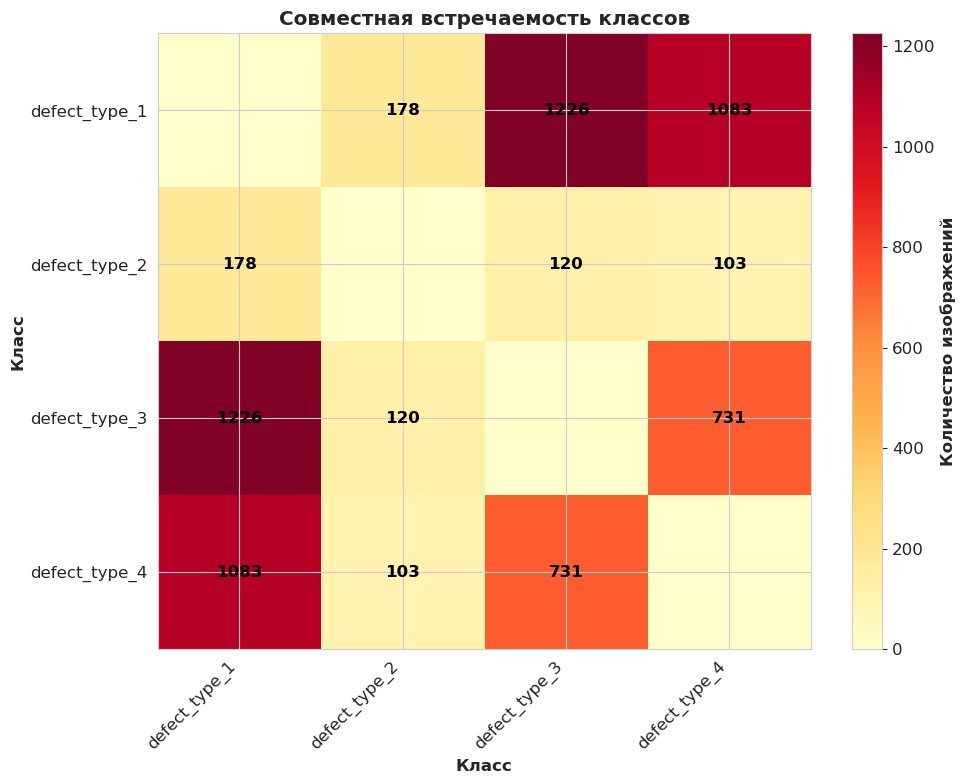

In [10]:
# Визуализация 2: Тепловая карта совместной встречаемости
if images_with_multiple_classes:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Создаем матрицу совместной встречаемости
    cooccur_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES))
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            if i != j:
                cooccur_matrix[i, j] = cooccurrence[i][j]
    
    # Тепловая карта
    im = ax.imshow(cooccur_matrix, cmap='YlOrRd', aspect='auto')
    
    # Подписи
    class_labels = [CLASS_NAMES[i] for i in range(NUM_CLASSES)]
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(class_labels, rotation=45, ha='right')
    ax.set_yticklabels(class_labels)
    ax.set_xlabel('Класс', fontweight='bold')
    ax.set_ylabel('Класс', fontweight='bold')
    ax.set_title('Совместная встречаемость классов', fontweight='bold')
    
    # Добавляем значения в ячейки
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            if i != j:
                text = ax.text(j, i, int(cooccur_matrix[i, j]),
                              ha="center", va="center", color="black", fontweight='bold')
    
    # Colorbar
    cbar = plt.colorbar(im)
    cbar.set_label('Количество изображений', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('cooccurrence_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

In [11]:
# Итоговая сводка
print("\n" + "="*80)
print("✅ ИТОГОВАЯ СВОДКА")
print("="*80)

# Создаем сводную таблицу
summary = {
    'Всего изображений': len(image_files),
    'Label файлов': len(all_label_files),
    'Изображений с дефектами': total_images_with_defects,
    'Пустых изображений': len(empty_images),
    'Всего BBox': total_bboxes,
    'Среднее BBox на изображение': f"{total_bboxes/total_images_with_defects:.2f}" if total_images_with_defects > 0 else "N/A",
    'Изображений с 1 классом': total_images_with_defects - len(images_with_multiple_classes),
    'Изображений с 2+ классами': len(images_with_multiple_classes)
}

for key, value in summary.items():
    print(f"   {key}: {value}")

print("\n📊 РАСПРЕДЕЛЕНИЕ ПО КЛАССАМ:")
for class_id in range(NUM_CLASSES):
    count = class_counter[class_id]
    pct = (count / total_bboxes * 100) if total_bboxes > 0 else 0
    print(f"   {CLASS_NAMES[class_id]}: {count} bbox ({pct:.1f}%)")

print("\n📁 Графики сохранены:")
print("   - synthetic_data_analysis.png")
if images_with_multiple_classes:
    print("   - cooccurrence_heatmap.png")


✅ ИТОГОВАЯ СВОДКА
   Всего изображений: 7336
   Label файлов: 7336
   Изображений с дефектами: 7336
   Пустых изображений: 0
   Всего BBox: 12467
   Среднее BBox на изображение: 1.70
   Изображений с 1 классом: 4651
   Изображений с 2+ классами: 2685

📊 РАСПРЕДЕЛЕНИЕ ПО КЛАССАМ:
   defect_type_1: 4932 bbox (39.6%)
   defect_type_2: 434 bbox (3.5%)
   defect_type_3: 3711 bbox (29.8%)
   defect_type_4: 3390 bbox (27.2%)

📁 Графики сохранены:
   - synthetic_data_analysis.png
   - cooccurrence_heatmap.png
